<a href="https://colab.research.google.com/github/aryank2074-ai/swiggy-bangalore-restaurant-analysis/blob/main/swiggy_project_new_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df=pd.read_csv("Swiggy Bangalore Outlet Details.csv")

In [ ]:
df.head()

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,₹ 150
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,₹ 400
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,₹ 126
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,₹ 400
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,₹ 450


In [ ]:
# How many features are there in datasets
df.columns

Index(['Shop_Name', 'Cuisine', 'Location', 'Rating', 'Cost_for_Two'], dtype='object')

In [ ]:
# Check for missing values in dataset
df.isnull().sum()

Shop_Name       0
Cuisine         0
Location        0
Rating          0
Cost_for_Two    0
dtype: int64

In [ ]:
df.info()  #logical structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Shop_Name     118 non-null    object
 1   Cuisine       118 non-null    object
 2   Location      118 non-null    object
 3   Rating        118 non-null    object
 4   Cost_for_Two  118 non-null    object
dtypes: object(5)
memory usage: 4.7+ KB


In [ ]:
df.duplicated().sum()  #identical rows

np.int64(0)

In [ ]:
# How many different ratings are there in dataset
df["Rating"].unique()

array(['4.3', '4.4', '4.1', '4.2', '3.9', '3.8', '4', '3.7', '3.6', '4.8',
       '4.5', '4.6', '--'], dtype=object)

In [ ]:
# Replace "--" rating with zero(0)
df["Rating"]=df["Rating"].str.replace("--","0").astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Shop_Name     118 non-null    object 
 1   Cuisine       118 non-null    object 
 2   Location      118 non-null    object 
 3   Rating        118 non-null    float64
 4   Cost_for_Two  118 non-null    object 
dtypes: float64(1), object(4)
memory usage: 4.7+ KB


In [ ]:
df["Cost_for_Two"].unique()

array(['₹ 150', '₹ 400', '₹ 126', '₹ 450', '₹ 350', '₹ 200', '₹ 500',
       '₹ 247', '₹ 550', '₹ 300', '₹ 129', '₹ 250', '₹ 268', '₹ 600',
       '₹ 527', '₹ 130', '₹ 257', '₹ 280', '₹ 399', '₹ 220', '₹ 800',
       '₹ 100', '₹ 178', '₹ 120', '₹ 251', '₹ 650', '₹ 132', '₹ 153',
       '₹ 219', '₹ 193'], dtype=object)

In [ ]:
# s1="₹ 150"
# int(s1.strip("₹ "))

In [ ]:
df["Cost_for_Two"]=df["Cost_for_Two"].apply(lambda x:int(x.strip("₹ ")))

In [ ]:
df["Cost_for_Two"].unique()

array([150, 400, 126, 450, 350, 200, 500, 247, 550, 300, 129, 250, 268,
       600, 527, 130, 257, 280, 399, 220, 800, 100, 178, 120, 251, 650,
       132, 153, 219, 193])

In [ ]:
df["Cost_for_Two"].dtype

dtype('int64')

In [ ]:
df.head()

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,150
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,400
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,126
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,400
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,450


In [ ]:
# Distribution of ratings
df_valid_ratings=df[df["Rating"]>0]
df_valid_ratings

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,150
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,400
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,126
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,400
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,450
...,...,...,...,...,...
113,Wok Paper Scissors,"Pan-Asian, Chinese, Asian","JNC Road, Koramangala",3.9,219
114,Savoury Restaurant,"Arabian, Middle Eastern, North Indian, Grill, ...","Madiwala, BTM",4.1,600
115,Royal Treat,"North Indian, Chinese, Seafood, Biryani","5th block Koramangala, Koramangala",4.2,193
116,Thali 99,North Indian,"Koramangala, Koramangala",4.3,200


C:\Users\aryan\AppData\Local\Temp\ipykernel_25596\1382112652.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_valid_ratings["Rating"])


<Axes: xlabel='Rating', ylabel='Density'>

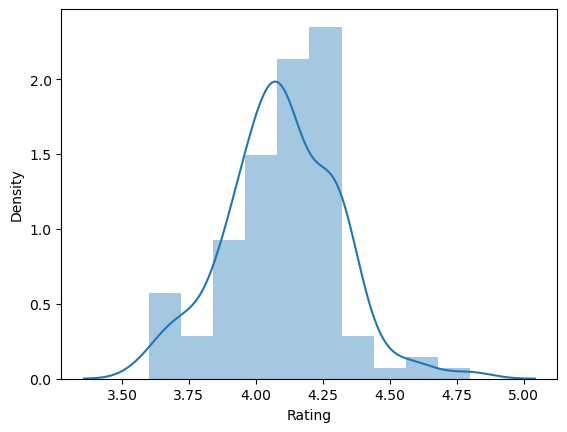

In [ ]:
# Distribution of rating
sns.distplot(df_valid_ratings["Rating"])

In [ ]:
# Handling feature----Location
df["Location"].unique()

array(['Koramangala, Koramangala', 'Sector 5, HSR',
       '6th Block, Koramangala', 'HSR, HSR', '5th Block, Koramangala',
       'Koramangala 4th  Block, Koramangala', 'BTM 2nd Stage, BTM',
       'BTM, BTM', '9th Main road, Koramangala', 'outer ring road, BTM',
       '7th Block, Koramangala', '1st MAin, Koramangala',
       'Bommanahalli, BTM', '6th block, Koramangala', 'Sector 4, HSR',
       'BTM 1st stage, BTM', 'Jakkasandra Extn, Koramangala',
       'Marutinagar Main Road, BTM', '1st Block, Koramangala',
       '4th Cross, BTM', 'koramangala, Koramangala', 'BTM 2nd stage, BTM',
       '3rd main, BTM', 'HSR 1st sector, HSR', 'Sector 7, HSR',
       '3rd Sector, HSR', 'Chocolate Factory Road, BTM',
       '16th Main Road, 2nd Stage, BTM', '1st Stage, BTM',
       'Hosur Main Road, Koramangala',
       '1st Cross Road, 5th Block, Near Jyothi Nivas College, Koramangala',
       'Mico Layout, BTM', '4th Cross, Koramangala',
       '4th Block, Koramangala', 'Intermediate Ring Road, K

In [ ]:
# Locations that contain koramangala
df_koramangala=df[df["Location"].str.contains("Koramangala")]

In [ ]:
df_koramangala

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,150
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,126
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,450
5,Kitchens of Punjab,North Indian,"Koramangala 4th Block, Koramangala",4.2,350
9,Yumlane Pizza,"Pizzas, Italian, Mexican","9th Main road, Koramangala",3.8,150
...,...,...,...,...,...
112,Kritunga,"Andhra, Biryani","5th Block, Koramangala",3.9,500
113,Wok Paper Scissors,"Pan-Asian, Chinese, Asian","JNC Road, Koramangala",3.9,219
115,Royal Treat,"North Indian, Chinese, Seafood, Biryani","5th block Koramangala, Koramangala",4.2,193
116,Thali 99,North Indian,"Koramangala, Koramangala",4.3,200


In [ ]:
#Locations that contains "HSR"
df_HSR=df[df["Location"].str.contains("HSR")]
df_HSR

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,400
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,400
8,Hotel Manu,"South Indian, Kerala, Chinese, North Indian","HSR, HSR",4.1,350
19,Shree Khana Khazana,"Indian, Rajasthani","Sector 4, HSR",4.1,350
24,New Udupi Grand,"Chinese, Jain, North Indian, South Indian","HSR, HSR",4.3,150
36,Biriyani Zone,"North Indian, Chinese, Biryani","HSR 1st sector, HSR",4.1,600
37,Gongura's,"North Indian, Chinese, Biryani","Sector 7, HSR",3.8,300
39,Leon Grill,"Turkish, Portuguese, American","3rd Sector, HSR",4.3,300
41,Cakewala,Desserts,"HSR, HSR",4.3,450
57,Donne Biriyani House,South Indian,"3rd sector, HSR",4.0,300


In [ ]:
#Locations that contains "BTM"
df_BTM=df[df["Location"].str.contains("BTM")]
df_BTM

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
6,99 VARIETY DOSA AND PAV BHAJI- Malli Mane Food...,"Fast Food, North Indian, Chinese","BTM 2nd Stage, BTM",4.1,200
7,La Pino'z Pizza,Italian,"BTM, BTM",3.9,500
10,Ambur Star Briyani,"Chinese, South Indian, North Indian, Desserts,...","outer ring road, BTM",4.1,500
17,Sri Lakshmi Dhaba,North Indian,"Bommanahalli, BTM",3.7,200
20,Just Bake - Cakes & confectioners,"Desserts, Bakery","BTM 1st stage, BTM",4.3,300
22,Hotel Godavari,"North Indian, Chinese, Hyderabadi","Marutinagar Main Road, BTM",4.0,400
25,Swad Punjab da,Indian,"BTM, BTM",4.1,250
27,High N Hungry,"Andhra, Biryani, Chinese, Desserts, Fast Food,...","4th Cross, BTM",4.1,350
31,Bengali Fun Foods,North Indian,"BTM 2nd stage, BTM",4.2,300
33,Oottupura,"Kerala, South Indian","BTM, BTM",4.3,268


<Axes: xlabel='Rating', ylabel='Count'>

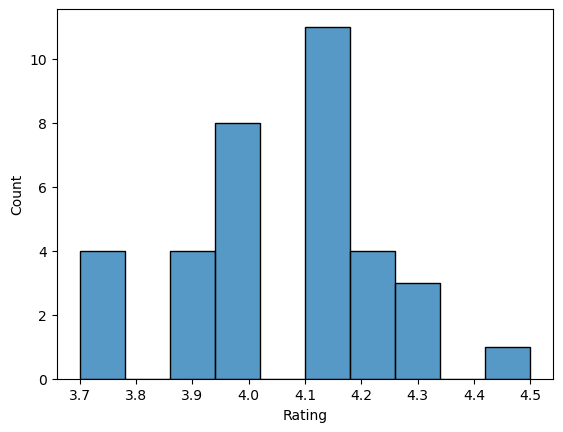

In [ ]:
sns.histplot(df_BTM["Rating"],bins=10)

<Axes: xlabel='Cost_for_Two', ylabel='Count'>

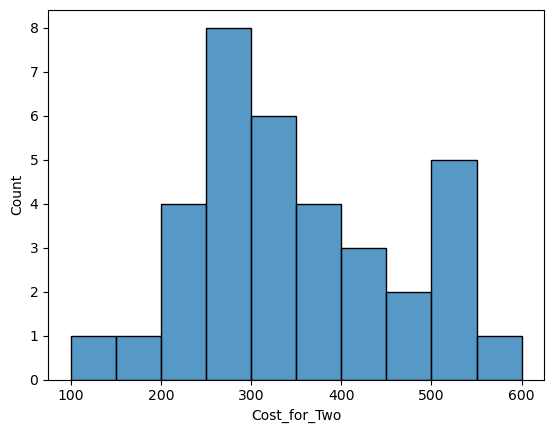

In [ ]:
sns.histplot(df_BTM["Cost_for_Two"],bins=10)

In [ ]:
# Conclusion:
# BTM:Most has 4.0 and 4.2 Rating and Approx.Cost for Two people lies between 200 to 350 (Max cost goes upto 600)

<Axes: xlabel='Rating', ylabel='Count'>

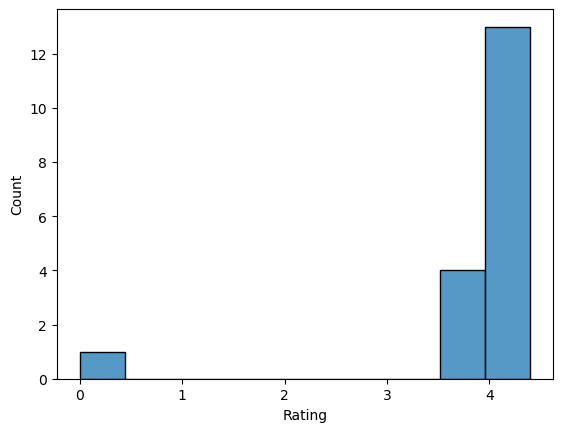

In [ ]:
#HSR Area
sns.histplot(df_HSR["Rating"],bins=10)

<Axes: xlabel='Cost_for_Two', ylabel='Count'>

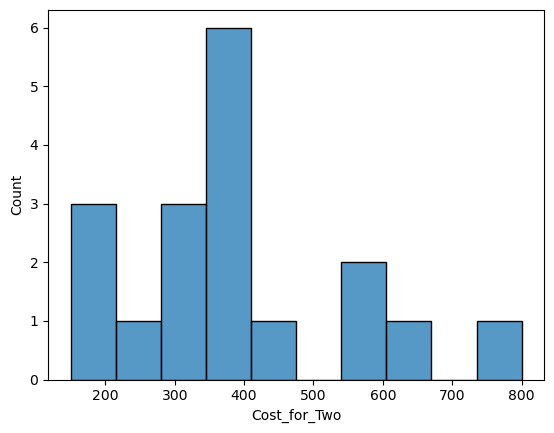

In [ ]:
sns.histplot(df_HSR["Cost_for_Two"],bins=10)

In [ ]:
# Conclusion:
# HSR:Most has 4.0 or above Rating and Approx.Cost for Two people lies between 300 to 400 (Max cost goes upto 800)

<Axes: xlabel='Rating', ylabel='Count'>

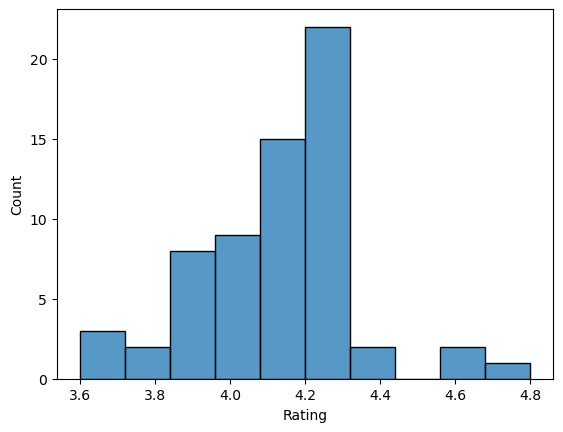

In [ ]:
# Koramangala Area
sns.histplot(df_koramangala["Rating"],bins=10)

<Axes: xlabel='Cost_for_Two', ylabel='Count'>

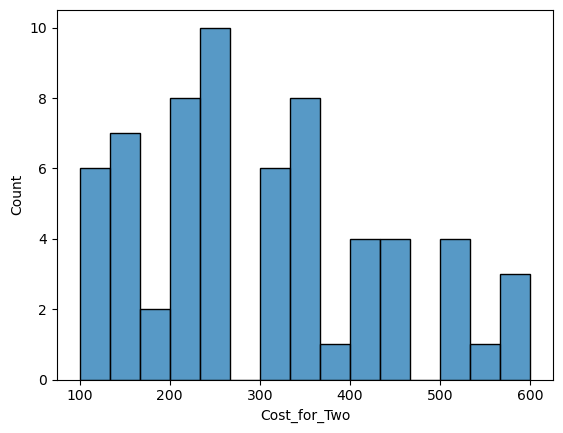

In [ ]:
sns.histplot(df_koramangala["Cost_for_Two"],bins=15)

In [ ]:
# Conclusion:
# Koramangala:Most has 4.0 and 4.3 Rating and Approx.Cost for Two people lies between 200 to 350 (Max cost goes upto 600)

In [ ]:
df_highest_rated_restaurants=df[df["Rating"]>=4.0]
df_highest_rated_restaurants

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,150
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,400
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,126
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,400
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,450
...,...,...,...,...,...
111,Bowl 99,"North Indian, South Indian","kormangala, Koramangala",4.4,200
114,Savoury Restaurant,"Arabian, Middle Eastern, North Indian, Grill, ...","Madiwala, BTM",4.1,600
115,Royal Treat,"North Indian, Chinese, Seafood, Biryani","5th block Koramangala, Koramangala",4.2,193
116,Thali 99,North Indian,"Koramangala, Koramangala",4.3,200


In [ ]:
df_highest_rated_restaurants=df_highest_rated_restaurants.loc[:,["Shop_Name","Rating","Cost_for_Two"]]

In [ ]:
df_highest_rated_restaurants

,Shop_Name,Rating,Cost_for_Two
0,Kanti Sweets,4.3,150
1,Mumbai Tiffin,4.4,400
2,Sri Krishna sagar,4.1,126
3,Al Daaz,4.4,400
4,Beijing Bites,4.1,450
...,...,...,...
111,Bowl 99,4.4,200
114,Savoury Restaurant,4.1,600
115,Royal Treat,4.2,193
116,Thali 99,4.3,200


In [ ]:
fig=px.scatter(
    x=df_highest_rated_restaurants["Cost_for_Two"],
    y=df_highest_rated_restaurants["Rating"],
    color=df_highest_rated_restaurants["Rating"],
    size=df_highest_rated_restaurants["Cost_for_Two"],
    labels={
        "x":"Approx.Cost_for_Two",
        "y":"Rating",
        "color":"Rating_Indicator"
    })
fig.update_layout(
    template="plotly_dark",
    title="Analyse 'Approx Cost for 2 People' vs 'Rating'")
fig.show()

In [ ]:
# Q. Analyze Affordable/Budgeted and Highest Rated Restaurants in Bangalore:
df_Affordable_Restaurants=df[(df["Cost_for_Two"]<=500)&(df["Rating"]>=4.0)]
df_Affordable_Restaurants

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,150
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,400
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,126
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,400
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,450
...,...,...,...,...,...
110,Biryani Pot,"North Indian, Biryani","Madiwala Junction, BTM",4.0,500
111,Bowl 99,"North Indian, South Indian","kormangala, Koramangala",4.4,200
115,Royal Treat,"North Indian, Chinese, Seafood, Biryani","5th block Koramangala, Koramangala",4.2,193
116,Thali 99,North Indian,"Koramangala, Koramangala",4.3,200


In [ ]:
df_Affordable_Restaurants=df_Affordable_Restaurants.loc[:,["Shop_Name","Rating","Cost_for_Two"]]
df_Affordable_Restaurants

,Shop_Name,Rating,Cost_for_Two
0,Kanti Sweets,4.3,150
1,Mumbai Tiffin,4.4,400
2,Sri Krishna sagar,4.1,126
3,Al Daaz,4.4,400
4,Beijing Bites,4.1,450
...,...,...,...
110,Biryani Pot,4.0,500
111,Bowl 99,4.4,200
115,Royal Treat,4.2,193
116,Thali 99,4.3,200


In [ ]:
df_Affordable_Restaurants.sort_values(by="Rating",ascending=False,inplace=True)
df_Affordable_Restaurants

,Shop_Name,Rating,Cost_for_Two
78,Khichdi Experiment,4.8,200
82,Natural Ice Cream,4.6,150
94,Corner House Ice Cream,4.6,250
80,Chinese Bae,4.5,450
1,Mumbai Tiffin,4.4,400
...,...,...,...
96,Just Shawarma,4.0,250
105,Paradise Biryani,4.0,300
110,Biryani Pot,4.0,500
106,New Tasty Cafeteria,4.0,350


C:\Users\aryan\AppData\Local\Temp\ipykernel_25596\133395867.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




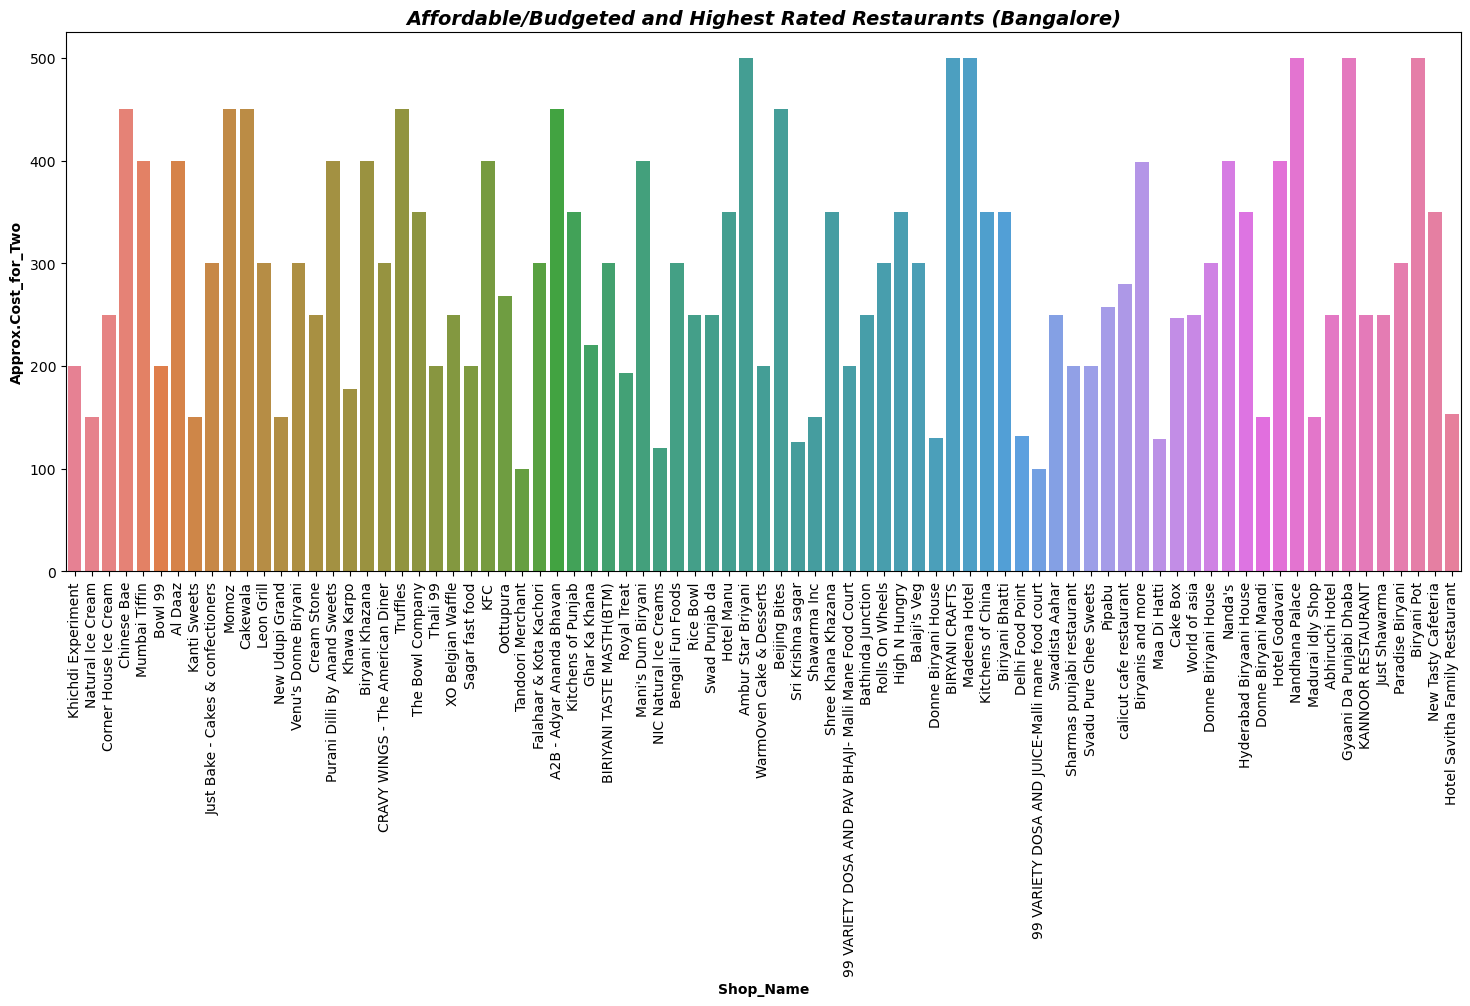

In [ ]:
plt.figure(figsize=(18,7))
sns.barplot(x="Shop_Name"
           ,y="Cost_for_Two",
           data=df_Affordable_Restaurants,palette="husl")
plt.title("Affordable/Budgeted and Highest Rated Restaurants (Bangalore)",
         fontsize=14,
         fontweight="bold",
         fontstyle="italic")
plt.xlabel("Shop_Name",fontsize=10,fontweight="bold")
plt.ylabel("Approx.Cost_for_Two",fontsize=10,fontweight="bold")
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Q.Top 15 Cheapest & Highest Rated Restaurant with Approx. Cost for 2 People:
df_Cheapest_Restaurants=df_Affordable_Restaurants.sort_values(by="Cost_for_Two",ascending=True)
df_Cheapest_Restaurants

,Shop_Name,Rating,Cost_for_Two
79,Tandoori Merchant,4.2,100
89,99 VARIETY DOSA AND JUICE-Malli mane food court,4.1,100
95,NIC Natural Ice Creams,4.2,120
2,Sri Krishna sagar,4.1,126
21,Maa Di Hatti,4.0,129
...,...,...,...
92,BIRYANI CRAFTS,4.1,500
10,Ambur Star Briyani,4.1,500
29,Nandhana Palace,4.0,500
110,Biryani Pot,4.0,500


In [ ]:
fig=px.bar(
    data_frame=df_Cheapest_Restaurants.head(15),
    x=df_Cheapest_Restaurants["Shop_Name"][0:15],
    y=df_Cheapest_Restaurants["Cost_for_Two"][0:15],
    color=df_Cheapest_Restaurants["Rating"][0:15],
    labels={"x":"Restaurant_Name",
           "y":"Approx.Cost_for_Two",
           "color":"Rating"}
)
fig.update_layout(
    template="plotly_dark",
    title="Top 15 Cheapest & Highest Rated Restuarants with Approx.Cost for 2 People",)
fig.show()

In [ ]:
df_Expensive_Restaurants=df_highest_rated_restaurants.sort_values(by="Cost_for_Two",ascending=False)
df_Expensive_Restaurants

,Shop_Name,Rating,Cost_for_Two
73,Punjabi Rasoi,4.0,800
99,Dindigul Thalapakatti Biriyani,4.1,650
34,Taco Bell,4.3,600
46,Pizza Hut,4.0,600
36,Biriyani Zone,4.1,600
...,...,...,...
21,Maa Di Hatti,4.0,129
2,Sri Krishna sagar,4.1,126
95,NIC Natural Ice Creams,4.2,120
89,99 VARIETY DOSA AND JUICE-Malli mane food court,4.1,100


In [ ]:
fig=px.bar(
    data_frame=df_Expensive_Restaurants.head(15),
    x=df_Expensive_Restaurants["Shop_Name"][0:15],
    y=df_Expensive_Restaurants["Cost_for_Two"][0:15],
    color=df_Expensive_Restaurants["Rating"][0:15],
    labels={"x":"Restaurant_Name",
           "y":"Approx.Cost_for_Two",
           "color":"Rating"}
)
fig.update_layout(
    template="plotly_dark",
    title="Top 15 Expensive & Highest Rated Restuarants with Approx.Cost for 2 People",)
fig.show()

In [ ]:
# Cuisine Analysis:
df["Cuisine"]=df["Cuisine"].str.title()
df["Cuisine"]

0                                                 Sweets
1                 North Indian, Home Food, Thalis, Combo
2      South Indian, North Indian, Fast Food, Beverag...
3      American, Arabian, Chinese, Desserts, Fast Foo...
4                                          Chinese, Thai
                             ...                        
113                            Pan-Asian, Chinese, Asian
114    Arabian, Middle Eastern, North Indian, Grill, ...
115              North Indian, Chinese, Seafood, Biryani
116                                         North Indian
117                                      Andhra, Biryani
Name: Cuisine, Length: 118, dtype: object

In [ ]:
# x={}
# for i in range(10):
    # name=input("enter the name")
    # if name in x:
        # x[name]=x[name]+1
    # else:
        # x[name]=1
    # print(x)

In [ ]:
freq_dict={}
for i in df["Cuisine"].unique():
    Cuisine_lists=i.split(",") #word list
    for Cuisine in Cuisine_lists:
        Cuisine=Cuisine.lstrip(" ") #remove left space
        if Cuisine in freq_dict:
            freq_dict[Cuisine]=freq_dict[Cuisine]+1
        else:
            freq_dict[Cuisine]=1
print(freq_dict)
print()
print("Total Records",len(freq_dict))

{'Sweets': 2, 'North Indian': 32, 'Home Food': 2, 'Thalis': 1, 'Combo': 1, 'South Indian': 23, 'Fast Food': 16, 'Beverages': 9, 'Jain': 2, 'American': 8, 'Arabian': 4, 'Chinese': 35, 'Desserts': 15, 'Mughlai': 7, 'Thai': 2, 'Italian': 4, 'Kerala': 6, 'Pizzas': 5, 'Mexican': 3, 'Andhra': 12, 'Seafood': 8, 'Biryani': 18, 'Indian': 5, 'Rajasthani': 1, 'Bakery': 2, 'Healthy Food': 4, 'Hyderabadi': 5, 'Snacks': 4, 'Turkish': 2, 'Portuguese': 2, 'Chaat': 2, 'Asian': 3, 'Continental': 3, 'Mediterranean': 1, 'Lebanese': 1, 'Cafe': 2, 'Salads': 2, 'Pastas': 1, 'Punjabi': 2, 'Juices': 2, 'Kebabs': 2, 'Grill': 2, 'Ice Cream': 2, 'Tandoor': 1, 'Chettinad': 2, 'Pan-Asian': 2, 'Oriental': 1, 'Middle Eastern': 1}

Total Records 48


In [ ]:
# Extracting Cuisine name and there frequency
Cuisine=freq_dict.keys()
freq=freq_dict.values()
df_Cuisine_Analysis=pd.DataFrame({"Cuisine":Cuisine,"Count":freq})
df_Cuisine_Analysis

,Cuisine,Count
0,Sweets,2
1,North Indian,32
2,Home Food,2
3,Thalis,1
4,Combo,1
5,South Indian,23
6,Fast Food,16
7,Beverages,9
8,Jain,2
9,American,8


C:\Users\aryan\AppData\Local\Temp\ipykernel_25596\150290855.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




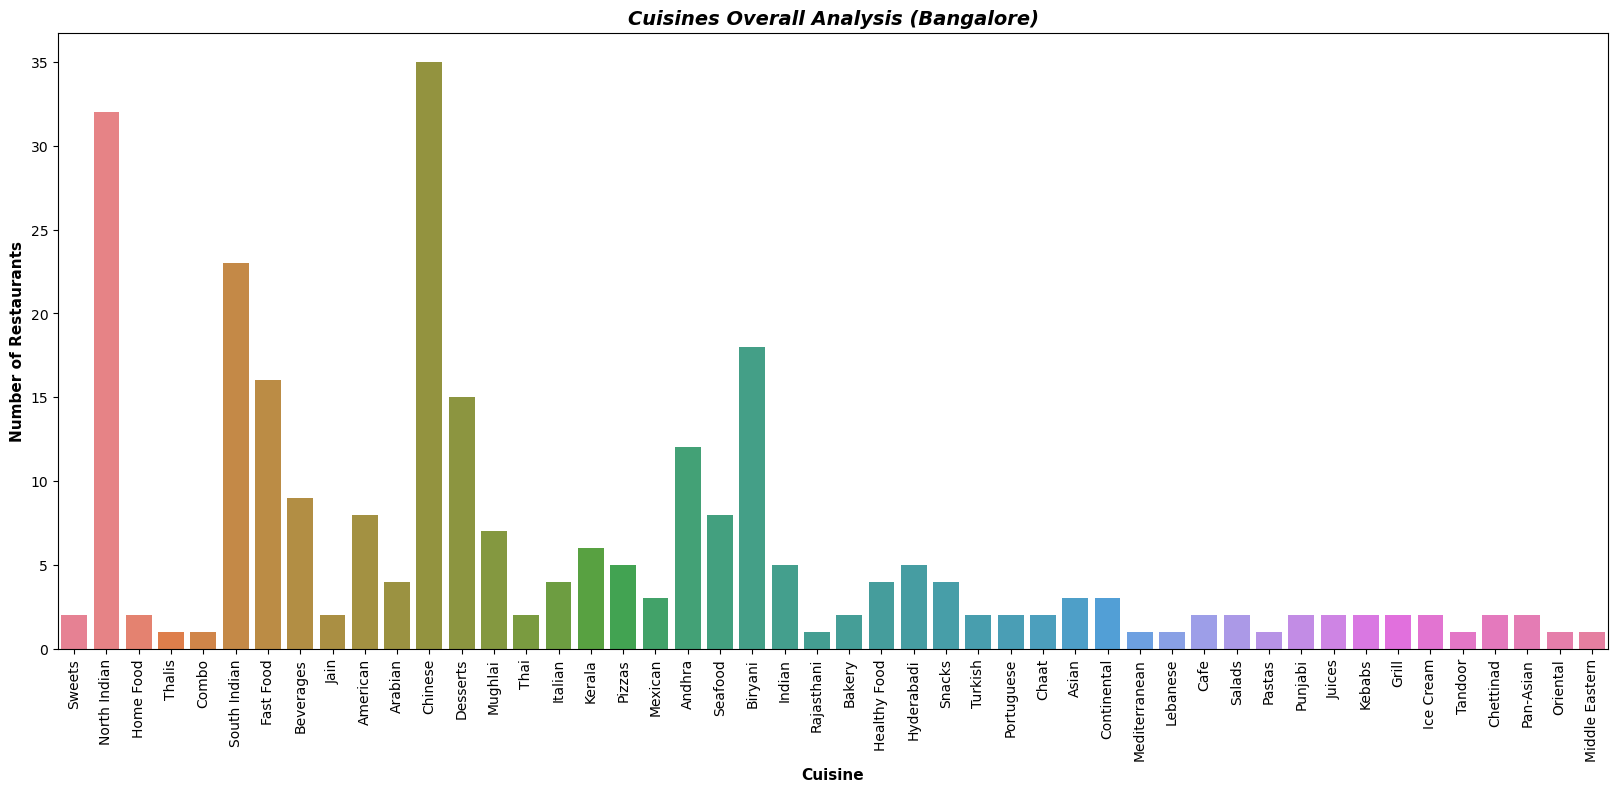

In [ ]:
plt.figure(figsize=(20,8))
sns.barplot(
    x="Cuisine",
    y="Count",
    data=df_Cuisine_Analysis,
    palette="husl"
)
plt.xticks(rotation=90)
plt.title(
    "Cuisines Overall Analysis (Bangalore)",
    fontsize=14,
    fontweight="bold",
    fontstyle="italic",
)
plt.xlabel("Cuisine",fontsize=11,fontweight="bold")
plt.ylabel("Number of Restaurants",fontsize=11,fontweight="bold")
plt.show()

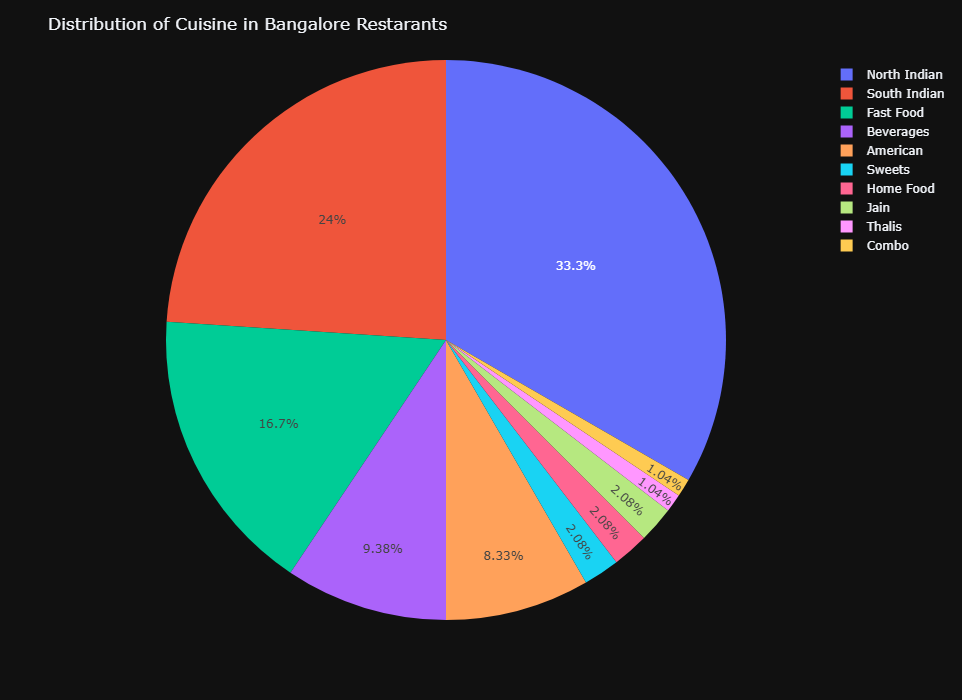

In [ ]:
fig=px.pie(
    data_frame=df_Cuisine_Analysis.head(10),
    names=df_Cuisine_Analysis["Cuisine"][:10],
    values=df_Cuisine_Analysis["Count"][:10],
)
fig.update_layout(
    template="plotly_dark",
    title="Distribution of Cuisine in Bangalore Restarants",width=700,height=700)
fig.show()

In [ ]:
df_BTM["Cuisine"].unique()

array(['Fast Food, North Indian, Chinese', 'Italian',
       'Chinese, South Indian, North Indian, Desserts, Fast Food, Kerala, Andhra, Beverages, Mughlai, Seafood',
       'North Indian', 'Desserts, Bakery',
       'North Indian, Chinese, Hyderabadi', 'Indian',
       'Andhra, Biryani, Chinese, Desserts, Fast Food, Seafood, South Indian',
       'Kerala, South Indian', 'North Indian, Chinese, Biryani',
       'Biryani', 'South Indian, Snacks, North Indian, Chinese',
       'Desserts, Fast Food, Sweets, Chaat',
       'Chinese, South Indian, Andhra, Hyderabadi',
       'North Indian, Chinese, South Indian',
       'Biryani, Andhra, South Indian', 'Fast Food, Beverages',
       'Beverages, Chinese', 'Kerala, Chinese', 'North Indian, Chinese',
       'Arabian, Beverages, Biryani, Chinese, Desserts, North Indian',
       'North Indian, South Indian', 'Chinese, Thai',
       'Chinese, Hyderabadi, Biryani, Indian, South Indian, Andhra, Tandoor',
       'Punjabi, North Indian, Chinese, Fast 

In [ ]:
freq_BTM={}
for i in df_BTM["Cuisine"].unique():
    Cuisine_lists=i.split(",") #word list
    for Cuisine in Cuisine_lists:
        Cuisine=Cuisine.lstrip(" ") #remove left space
        if Cuisine in freq_BTM:
            freq_BTM[Cuisine]=freq_BTM[Cuisine]+1
        else:
            freq_BTM[Cuisine]=1
print(freq_BTM)
print()
print("Total Records",len(freq_BTM))

{'Fast Food': 6, 'North Indian': 16, 'Chinese': 18, 'Italian': 1, 'South Indian': 10, 'Desserts': 6, 'Kerala': 4, 'Andhra': 7, 'Beverages': 4, 'Mughlai': 3, 'Seafood': 3, 'Bakery': 1, 'Hyderabadi': 4, 'Indian': 2, 'Biryani': 8, 'Snacks': 1, 'Sweets': 1, 'Chaat': 1, 'Arabian': 2, 'Thai': 1, 'Tandoor': 1, 'Punjabi': 1, 'Healthy Food': 1, 'Chettinad': 1, 'Middle Eastern': 1, 'Grill': 1}

Total Records 26


In [ ]:
Cuisine=freq_BTM.keys()
freq=freq_BTM.values()
dict_BTM={"Cuisine":Cuisine,"Count":freq}
df_Cuisine_BTM=pd.DataFrame(dict_BTM)
df_Cuisine_BTM.head()

,Cuisine,Count
0,Fast Food,6
1,North Indian,16
2,Chinese,18
3,Italian,1
4,South Indian,10


C:\Users\aryan\AppData\Local\Temp\ipykernel_25596\1482546176.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




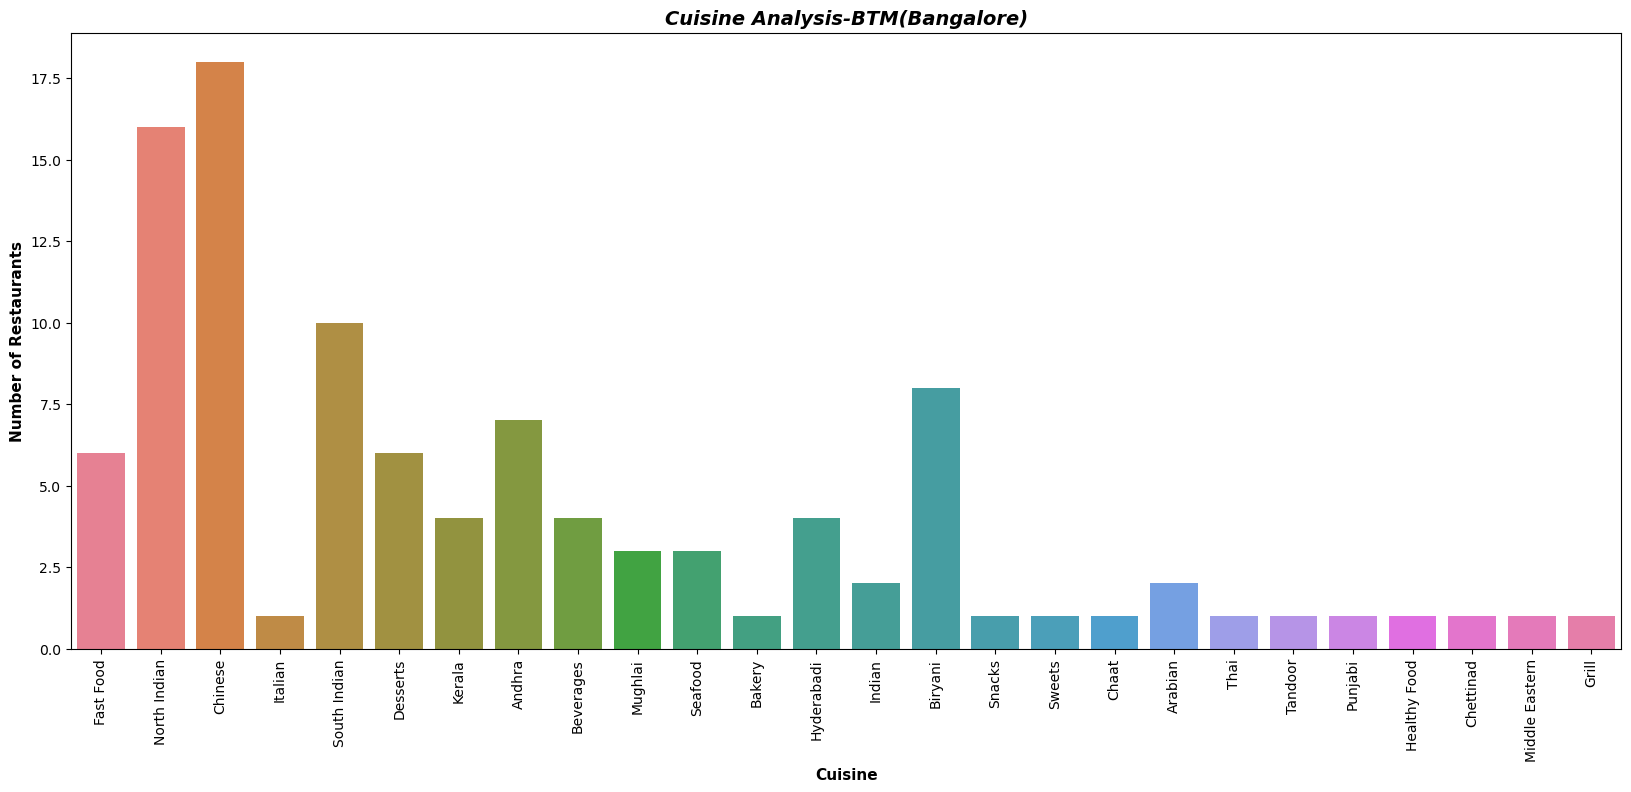

In [ ]:
plt.figure(figsize=(20,8))
sns.barplot(x="Cuisine",y="Count",data=df_Cuisine_BTM,palette="husl")
plt.xticks(rotation=90)
plt.title(
    "Cuisine Analysis-BTM(Bangalore)",
    fontsize=14,
    fontweight="bold",
    fontstyle="italic")
plt.xlabel("Cuisine",fontsize=11,fontweight="bold")
plt.ylabel("Number of Restaurants",fontsize=11,fontweight="bold")
plt.show()

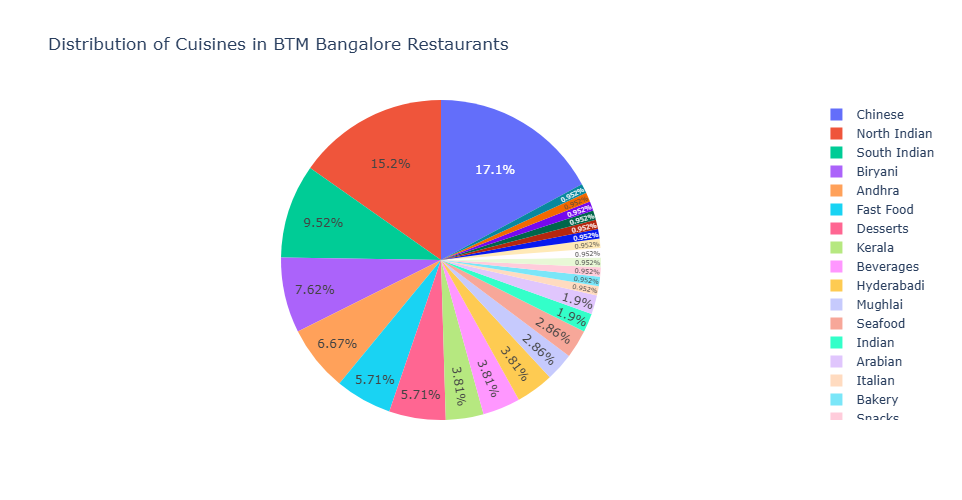

In [ ]:
fig=px.pie(
    data_frame=df_Cuisine_BTM,
    names=df_Cuisine_BTM["Cuisine"],
    values=df_Cuisine_BTM["Count"],
    title="Distribution of Cuisines in BTM Bangalore Restaurants",height=500,width=500)
fig.update_traces(textposition="inside")
fig.show()

In [ ]:
df_HSR["Cuisine"].unique()

array(['North Indian, Home Food, Thalis, Combo',
       'American, Arabian, Chinese, Desserts, Fast Food, Mughlai, North Indian',
       'South Indian, Kerala, Chinese, North Indian',
       'Indian, Rajasthani', 'Chinese, Jain, North Indian, South Indian',
       'North Indian, Chinese, Biryani', 'Turkish, Portuguese, American',
       'Desserts', 'South Indian', 'Andhra, Biryani', 'Desserts, Bakery',
       'Biryani, Juices, Kebabs', 'North Indian', 'Biryani',
       'Snacks, American', 'Chettinad, South Indian'], dtype=object)

In [ ]:
freq_HSR={}
for i in df_HSR["Cuisine"].unique():
    Cuisine_lists=i.split(",") #word list
    for Cuisine in Cuisine_lists:
        Cuisine=Cuisine.lstrip(" ") #remove left space
        if Cuisine in freq_HSR:
            freq_HSR[Cuisine]=freq_HSR[Cuisine]+1
        else:
            freq_HSR[Cuisine]=1
print(freq_HSR)
print()
print("Total Records",len(freq_HSR))

{'North Indian': 6, 'Home Food': 1, 'Thalis': 1, 'Combo': 1, 'American': 3, 'Arabian': 1, 'Chinese': 4, 'Desserts': 3, 'Fast Food': 1, 'Mughlai': 1, 'South Indian': 4, 'Kerala': 1, 'Indian': 1, 'Rajasthani': 1, 'Jain': 1, 'Biryani': 4, 'Turkish': 1, 'Portuguese': 1, 'Andhra': 1, 'Bakery': 1, 'Juices': 1, 'Kebabs': 1, 'Snacks': 1, 'Chettinad': 1}

Total Records 24


In [ ]:
Cuisine=freq_HSR.keys()
freq=freq_HSR.values()
dict_HSR={"Cuisine":Cuisine,"Count":freq}
df_Cuisine_HSR=pd.DataFrame(dict_HSR)
df_Cuisine_HSR.head()

,Cuisine,Count
0,North Indian,6
1,Home Food,1
2,Thalis,1
3,Combo,1
4,American,3


C:\Users\aryan\AppData\Local\Temp\ipykernel_25596\22619581.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




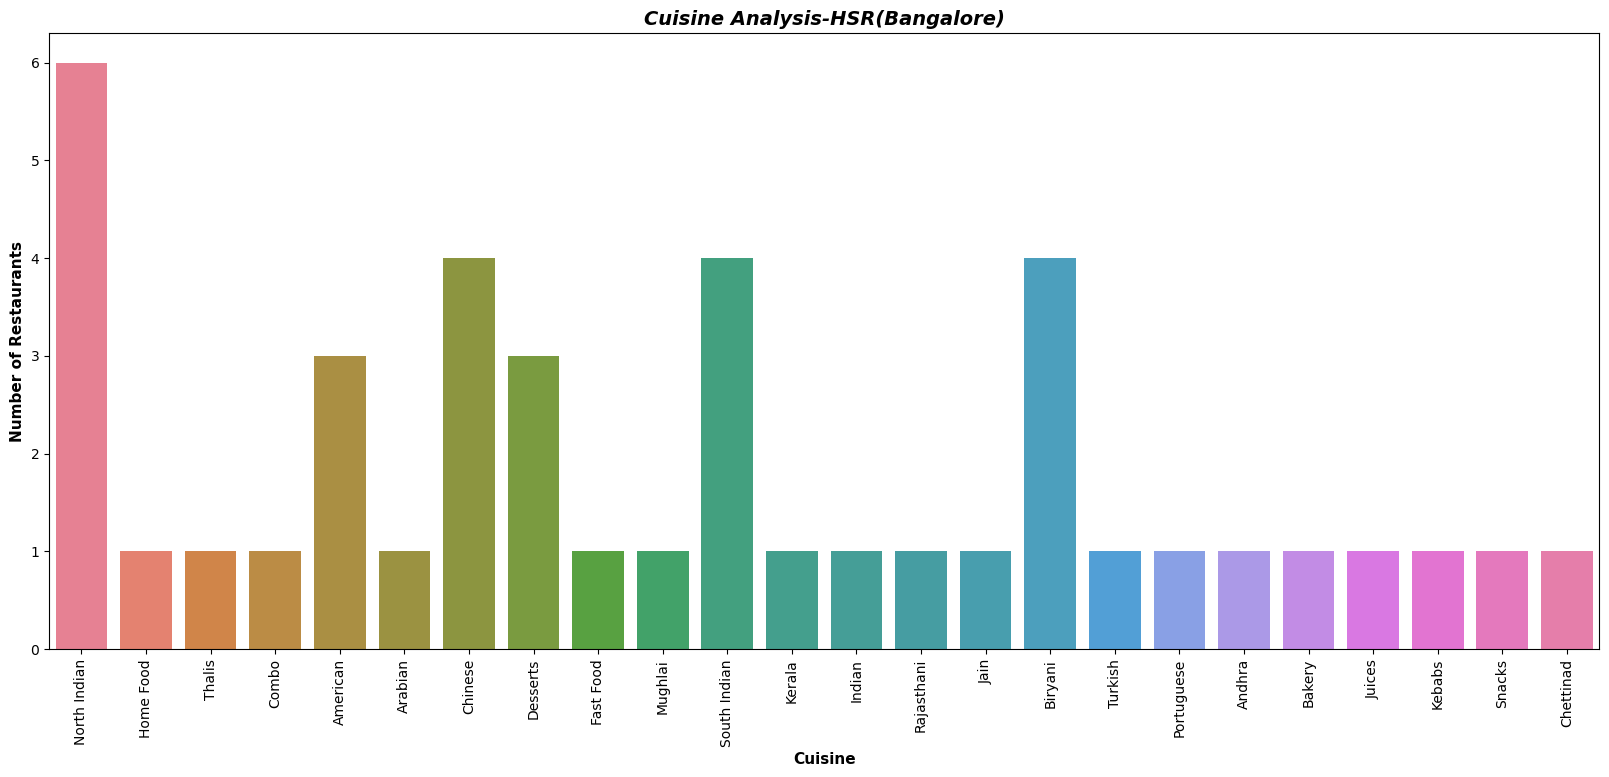

In [ ]:
plt.figure(figsize=(20,8))
sns.barplot(x="Cuisine",y="Count",data=df_Cuisine_HSR,palette="husl")
plt.xticks(rotation=90)
plt.title(
    "Cuisine Analysis-HSR(Bangalore)",
    fontsize=14,
    fontweight="bold",
    fontstyle="italic")
plt.xlabel("Cuisine",fontsize=11,fontweight="bold")
plt.ylabel("Number of Restaurants",fontsize=11,fontweight="bold")
plt.show()

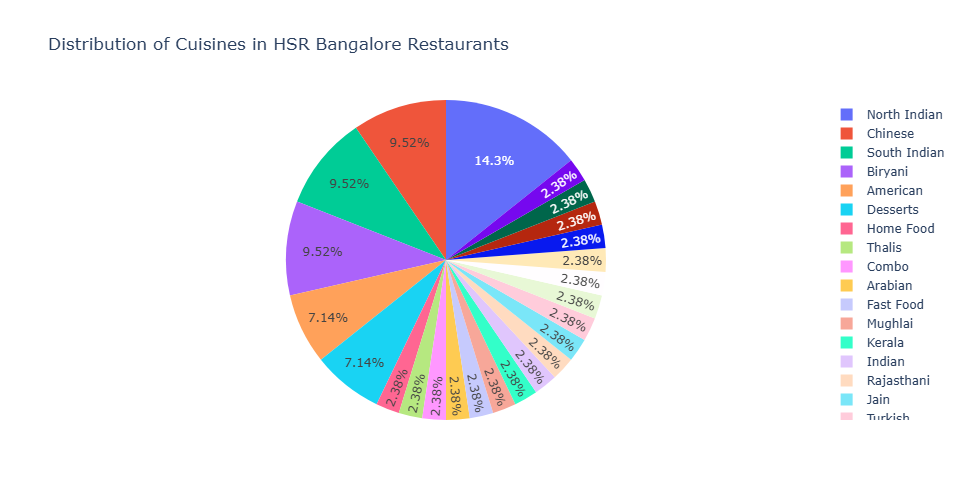

In [ ]:
fig=px.pie(
    data_frame=df_Cuisine_HSR,
    names=df_Cuisine_HSR["Cuisine"],
    values=df_Cuisine_HSR["Count"],
    title="Distribution of Cuisines in HSR Bangalore Restaurants",height=500,width=500)
fig.update_traces(textposition="inside")
fig.show()

In [ ]:
df_koramangala["Cuisine"].unique()

array(['Sweets', 'South Indian, North Indian, Fast Food, Beverages, Jain',
       'Chinese, Thai', 'North Indian', 'Pizzas, Italian, Mexican',
       'Desserts', 'Chinese, Andhra, Biryani, Seafood', 'Chinese',
       'South Indian, Chinese, Desserts, North Indian',
       'Arabian, Fast Food', 'Desserts, Beverages',
       'Chinese, Healthy Food, North Indian', 'Fast Food',
       'North Indian, South Indian, Chinese', 'American, Fast Food',
       'Biryani, Seafood, North Indian, Chinese, Desserts, Andhra, South Indian',
       'Snacks, American', 'South Indian', 'Mexican', 'Pizzas, Fast Food',
       'Biryani, Mughlai, South Indian', 'Chinese, Asian',
       'Italian, Desserts, Pizzas',
       'Chinese, Continental, Italian, Mediterranean, Thai, Lebanese, American, Asian, Beverages, Bakery, Biryani, Cafe, Desserts, Healthy Food, Mexican, North Indian, Salads, Pizzas',
       'Biryani',
       'Pizzas, Chinese, Pastas, Salads, American, Continental',
       'Chinese, South Indian, Nor

In [ ]:
freq_koramangala={}
for i in df_koramangala["Cuisine"].unique():
    Cuisine_lists=i.split(",") #word list
    for Cuisine in Cuisine_lists:
        Cuisine=Cuisine.lstrip(" ") #remove left space
        if Cuisine in freq_koramangala:
            freq_koramangala[Cuisine]=freq_koramangala[Cuisine]+1
        else:
            freq_koramangala[Cuisine]=1
print(freq_koramangala)
print()
print("Total Records",len(freq_koramangala))

{'Sweets': 1, 'South Indian': 11, 'North Indian': 14, 'Fast Food': 9, 'Beverages': 5, 'Jain': 1, 'Chinese': 15, 'Thai': 2, 'Pizzas': 5, 'Italian': 4, 'Mexican': 3, 'Desserts': 8, 'Andhra': 5, 'Biryani': 10, 'Seafood': 5, 'Arabian': 1, 'Healthy Food': 3, 'American': 6, 'Snacks': 3, 'Mughlai': 3, 'Asian': 3, 'Continental': 3, 'Mediterranean': 1, 'Lebanese': 1, 'Bakery': 1, 'Cafe': 2, 'Salads': 2, 'Pastas': 1, 'Punjabi': 1, 'Hyderabadi': 1, 'Kerala': 1, 'Turkish': 1, 'Portuguese': 1, 'Grill': 1, 'Home Food': 1, 'Indian': 2, 'Ice Cream': 2, 'Juices': 1, 'Chaat': 1, 'Kebabs': 1, 'Pan-Asian': 2, 'Oriental': 1}

Total Records 42


In [ ]:
Cuisine=freq_koramangala.keys()
freq=freq_koramangala.values()
dict_koramangala={"Cuisine":Cuisine,"Count":freq}
df_Cuisine_koramangala=pd.DataFrame(dict_koramangala)
df_Cuisine_koramangala.head()

,Cuisine,Count
0,Sweets,1
1,South Indian,11
2,North Indian,14
3,Fast Food,9
4,Beverages,5


C:\Users\aryan\AppData\Local\Temp\ipykernel_25596\4203946531.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




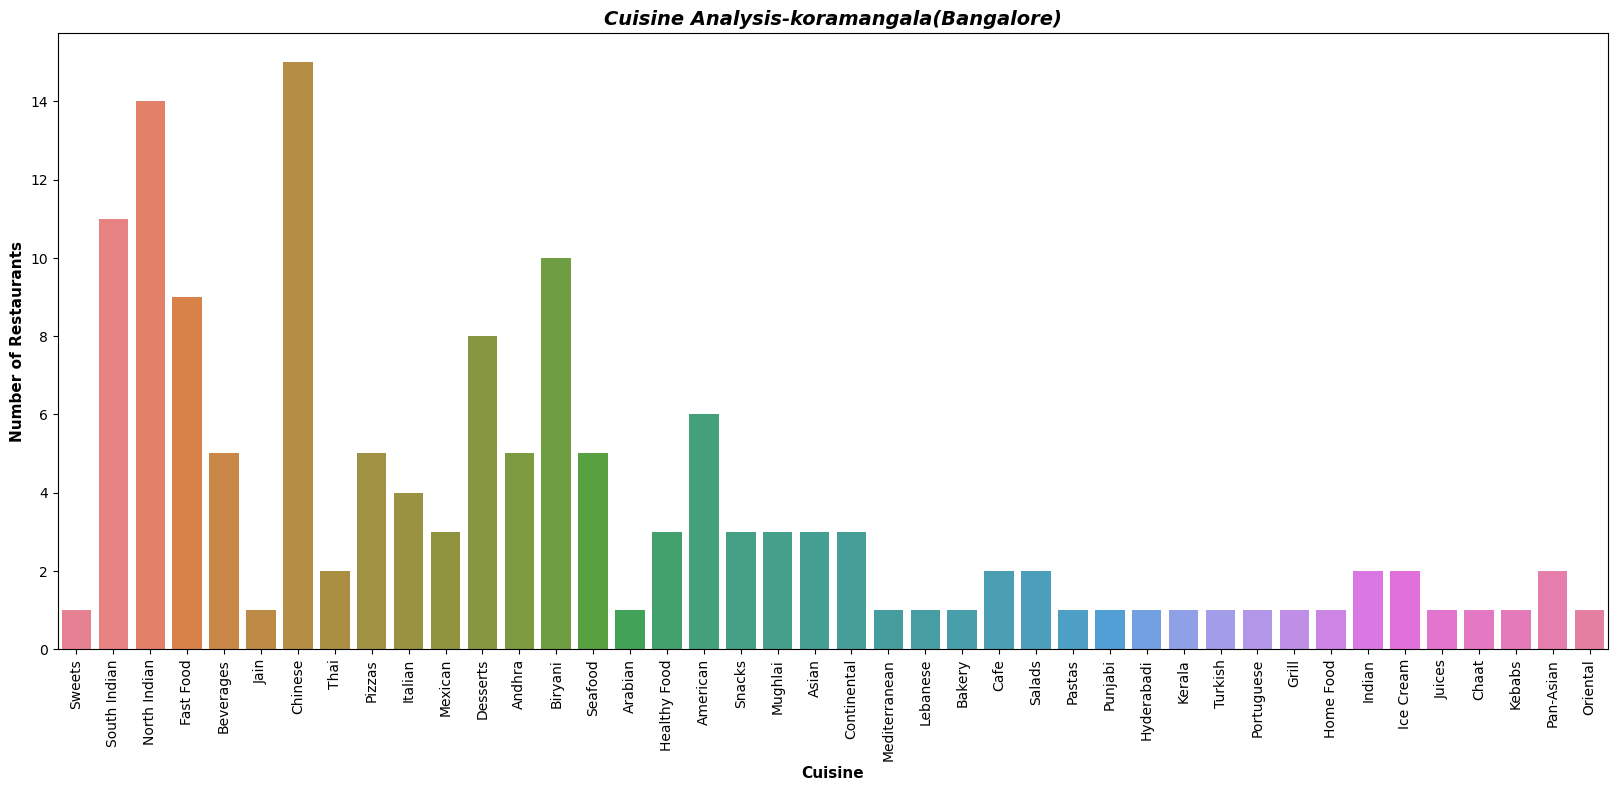

In [ ]:
plt.figure(figsize=(20,8))
sns.barplot(x="Cuisine",y="Count",data=df_Cuisine_koramangala,palette="husl")
plt.xticks(rotation=90)
plt.title(
    "Cuisine Analysis-koramangala(Bangalore)",
    fontsize=14,
    fontweight="bold",
    fontstyle="italic")
plt.xlabel("Cuisine",fontsize=11,fontweight="bold")
plt.ylabel("Number of Restaurants",fontsize=11,fontweight="bold")
plt.show()

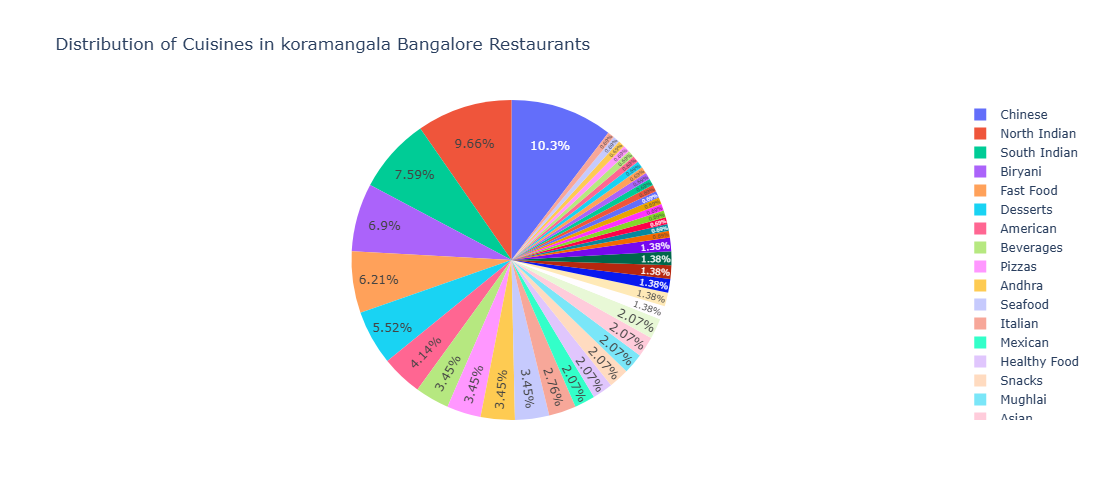

In [ ]:
fig=px.pie(
    data_frame=df_Cuisine_koramangala,
    names=df_Cuisine_koramangala["Cuisine"],
    values=df_Cuisine_koramangala["Count"],
    title="Distribution of Cuisines in koramangala Bangalore Restaurants",height=500,width=500)
fig.update_traces(textposition="inside")
fig.show()